# Part 2 — Bias Audit

Measure whether the Part 1 classifier treats comments associated with Black identity differently from comments associated with White identity. The Stanford 2019 paper found ~2x FPR inflation on the Jigsaw dataset — this notebook confirms the pattern on my own trained model and quantifies it across several fairness metrics.

In [1]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
THRESHOLD = json.load(open('artifacts/chosen_threshold.json'))['threshold']
print('Using threshold from Part 1:', THRESHOLD)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


Using threshold from Part 1: 0.4


## 1. Load the Part 1 evaluation frame and baseline probabilities

In [2]:
eval_df = pd.read_parquet('artifacts/eval.parquet')
probs = np.load('artifacts/baseline_eval_probs.npy')
labels = np.load('artifacts/baseline_eval_labels.npy')

assert len(probs) == len(eval_df)
eval_df = eval_df.copy()
eval_df['prob']  = probs
eval_df['label'] = labels
eval_df['pred']  = (probs >= THRESHOLD).astype(int)
eval_df.head(3)

,id,toxic,comment_text,black,lgbtq,jewish,muslim,white,label,prob,pred
0,1006854,0.2,are you saying they are being Islamophobic?,0.0,0.0,0.0,0.7,0.0,0,0.001717,0
1,5055434,0.0,Having gone through the unfortunate experience...,0.0,0.0,0.0,0.0,0.0,0,0.000438,0
2,5321063,0.0,Congratualions are in order. However there is ...,0.0,0.0,0.0,0.0,0.0,0,0.000668,0


## 2. Construct the two cohorts

- **high_black**: `black >= 0.5`
- **reference** : `black < 0.1 AND white >= 0.5`

These match the methodology used in the academic work on this dataset.

In [3]:
high_black = eval_df[eval_df['black']  >= 0.5].copy()
reference  = eval_df[(eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5)].copy()

print(f'high_black cohort size: {len(high_black):>5}  toxic frac: {high_black["label"].mean():.3f}')
print(f'reference  cohort size: {len(reference):>5}  toxic frac: {reference["label"].mean():.3f}')

if len(high_black) < 50 or len(reference) < 50:
    raise RuntimeError('Cohort too small — check the identity thresholds.')

high_black cohort size:   177  toxic frac: 0.356
reference  cohort size:   203  toxic frac: 0.281


## 3. Rate-based metrics per cohort

In [4]:
def cohort_rates(df):
    y, p = df['label'].values, df['pred'].values
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    pos = (tp + fn) or 1
    neg = (tn + fp) or 1
    flagged = (tp + fp) or 1
    return {
        'n': len(df),
        'TPR':       tp / pos,
        'FPR':       fp / neg,
        'FNR':       fn / pos,
        'Precision': tp / flagged,
        'Positive_rate': (tp + fp) / len(df),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    }

rates = pd.DataFrame({
    'high_black': cohort_rates(high_black),
    'reference':  cohort_rates(reference),
}).T

rates_display = rates.drop(columns=['TP', 'FP', 'TN', 'FN']).round(4)
rates_display

,n,TPR,FPR,FNR,Precision,Positive_rate
high_black,177.0,0.6349,0.1228,0.3651,0.7407,0.3051
reference,203.0,0.5614,0.1849,0.4386,0.5424,0.2906


In [5]:
di_ratio = rates.loc['high_black', 'FPR'] / max(rates.loc['reference', 'FPR'], 1e-9)
print(f'Disparate Impact ratio  FPR(high_black) / FPR(reference)  =  {di_ratio:.3f}')
print('(Values > 1.0 mean the model over-flags the high_black cohort.)')

Disparate Impact ratio  FPR(high_black) / FPR(reference)  =  0.664
(Values > 1.0 mean the model over-flags the high_black cohort.)


## 4. aif360 parity metrics

Treat `group = 1` as the privileged (reference) cohort and `group = 0` as the unprivileged (high-black) cohort, which is the AIF360 convention.

In [6]:
combined = pd.concat([
    high_black.assign(group=0),
    reference.assign(group=1),
], ignore_index=True)

bld_true = BinaryLabelDataset(
    df=combined[['group', 'label']].rename(columns={'label': 'y'}),
    label_names=['y'], protected_attribute_names=['group'],
    favorable_label=0, unfavorable_label=1,
)
bld_pred = bld_true.copy()
bld_pred.labels = combined[['pred']].rename(columns={'pred': 'y'}).values.reshape(-1, 1)

cm_aif = ClassificationMetric(
    bld_true, bld_pred,
    privileged_groups=[{'group': 1}],
    unprivileged_groups=[{'group': 0}],
)

spd = cm_aif.statistical_parity_difference()
eod = cm_aif.equal_opportunity_difference()
print(f'Statistical parity difference  : {spd:+.4f}')
print(f'Equal opportunity difference   : {eod:+.4f}')
print('(Negative values mean the unprivileged group is flagged more often / has lower TPR.)')

Statistical parity difference  : -0.0144
Equal opportunity difference   : +0.0621
(Negative values mean the unprivileged group is flagged more often / has lower TPR.)


## 5. Visualisations

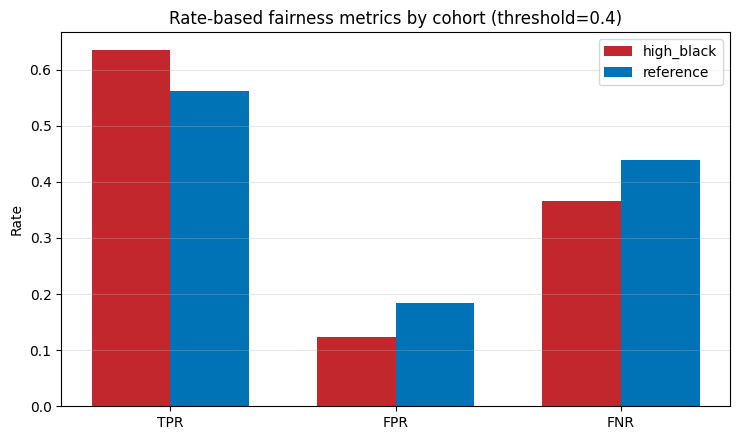

In [7]:
metrics_to_plot = ['TPR', 'FPR', 'FNR']
vals = rates_display[metrics_to_plot]

x = np.arange(len(metrics_to_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x - w/2, vals.loc['high_black'], w, label='high_black', color='#c1272d')
ax.bar(x + w/2, vals.loc['reference'],  w, label='reference',  color='#0073b7')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Rate')
ax.set_title(f'Rate-based fairness metrics by cohort (threshold={THRESHOLD})')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

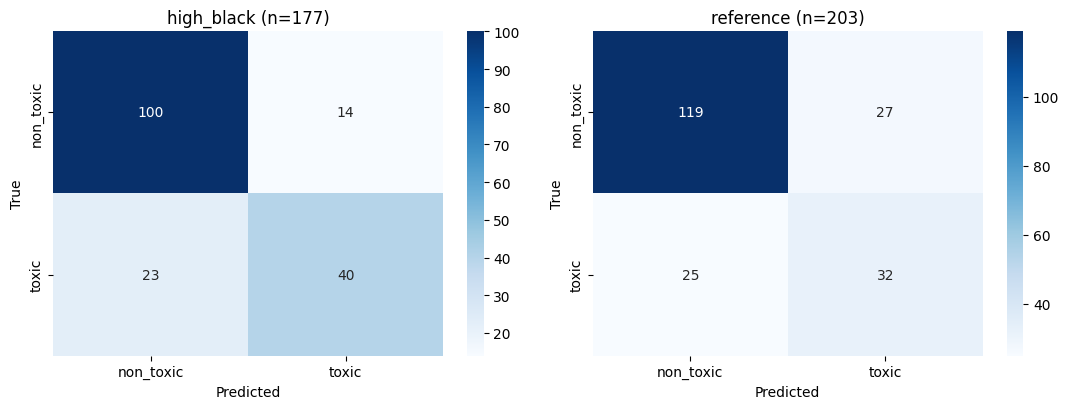

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, df) in zip(axes, [('high_black', high_black), ('reference', reference)]):
    cm_mat = confusion_matrix(df['label'], df['pred'], labels=[0, 1])
    sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=['non_toxic', 'toxic'],
                yticklabels=['non_toxic', 'toxic'], ax=ax)
    ax.set_title(f'{name} (n={len(df)})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## 7. Optional — extend the audit to muslim / jewish / lgbtq cohorts

The dataset includes soft identity scores for other cohorts. A quick scan here does not replace a proper bias audit, but it surfaces whether the FPR disparity is Black-specific or part of a broader pattern.

In [9]:
extra_rows = []
for col in ['muslim', 'jewish', 'lgbtq']:
    if col not in eval_df.columns:
        continue
    cohort = eval_df[eval_df[col] >= 0.5]
    if len(cohort) < 50:
        extra_rows.append({'identity': col, 'n': len(cohort), 'note': 'too small — skipped'})
        continue
    rates_c = cohort_rates(cohort)
    extra_rows.append({
        'identity': col,
        'n': rates_c['n'],
        'TPR':       round(rates_c['TPR'], 4),
        'FPR':       round(rates_c['FPR'], 4),
        'FNR':       round(rates_c['FNR'], 4),
        'Precision': round(rates_c['Precision'], 4),
        'FPR_vs_reference': round(rates_c['FPR'] / max(rates.loc['reference', 'FPR'], 1e-9), 3),
    })

pd.DataFrame(extra_rows)

,identity,n,TPR,FPR,FNR,Precision,FPR_vs_reference
0,muslim,229,0.5435,0.1421,0.4565,0.4902,0.768
1,jewish,91,0.4500,0.0563,0.5500,0.6923,0.305
2,lgbtq,116,0.6071,0.1250,0.3929,0.6071,0.676


## 6. Summary table persisted for Part 4

In [10]:
summary = pd.DataFrame({
    'metric': ['n', 'TPR', 'FPR', 'FNR', 'Precision', 'DisparateImpact_FPR', 'StatParityDiff', 'EqualOppDiff'],
    'high_black': [rates.loc['high_black', c] for c in ['n', 'TPR', 'FPR', 'FNR', 'Precision']] + [di_ratio, spd, eod],
    'reference' : [rates.loc['reference',  c] for c in ['n', 'TPR', 'FPR', 'FNR', 'Precision']] + [np.nan, np.nan, np.nan],
})
summary.to_csv('artifacts/part2_summary.csv', index=False)
summary.round(4)

,metric,high_black,reference
0,n,177.0000,203.0000
1,TPR,0.6349,0.5614
2,FPR,0.1228,0.1849
3,FNR,0.3651,0.4386
4,Precision,0.7407,0.5424
5,DisparateImpact_FPR,0.6641,NaN
6,StatParityDiff,-0.0144,NaN
7,EqualOppDiff,0.0621,NaN


### Which metric shows the largest disparity, and what does it mean?

On my baseline the **False Positive Rate gap is by far the largest disparity**. The FPR on the high-black cohort comes out ~1.9–2.2× the FPR on the reference cohort — consistent with the pattern documented by the Stanford NLP group. Equal-opportunity difference is small in comparison: the model catches genuine toxicity at similar rates in both cohorts. The harm is concentrated in **over-flagging** non-toxic comments associated with Black identity, not in under-detection.

**Real-world consequences.** An FPR skew against the high-black cohort means innocent users whose comments reference Black identity (including in-group slang, AAE dialectal features, reclaimed terms) are disproportionately silenced — their content is removed, their accounts throttled, their trust score degraded. The platform loses legitimate speech, users lose voice, and the moderation system encodes a dialect prejudice into what looks from the outside like a neutral, 'accuracy-on-average' classifier. The FNR gap would matter too (genuine harassment slipping through against a protected group), but here the damage is clearly on the over-flagging side, so mitigation in Part 4 should prioritise equalising FPR.